<a href="https://colab.research.google.com/github/gonzaloangaut/NeuralNetworks/blob/main/Practicos/redes_neuronales_2023_practico_5_Angaut.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# El modelo *Integrate and Fire*

## Teoría

El modelo *Integrate and Fire* del comportamiento de una neurona viene descripto por dos ingredientes. En primer lugar, la ODE

\begin{eqnarray}
\frac{dV}{dt}
&=&
\frac{1}{\tau}
\left(
E-V(t)
+
RI(t)
\right)
\end{eqnarray}

donde:

* $V(t)$ representa el potencial de membrana al tiempo $t$,

* $E\approx -65mV$ representa el potencial de reposo,

* $\tau\approx 10ms$ representa el tiempo de relajación,

* $R\approx 10M\Omega$ representa una resistencia eléctrica, y

* $I(t)\approx 1nA$ representa una corriente/señal de entrada.

En segundo lugar, un mecanismo de disparo definido por

\begin{eqnarray}
V(t) \to E
\end{eqnarray}

cuando

\begin{eqnarray}
V(t) > V_u
\end{eqnarray}

donde:

* $V_u \approx -50mV$ representa un potencial umbral.

Es decir, según el mecanismo de disparo, el potencial de membrana $V(t)$ se resetea a su valor de reposo $E$ si supera cierto valor umbral $V_u$.

## Unidades

* p = pico = $10^{-12}$
* n = nano = $10^{-9}$
* $\mu$ = micro = $10^{-6}$
* m = mili = $10^{-3}$
* ...
* k = kilo = $10^{3}$
* M = Mega = $10^{6}$
* G = Giga = $10^{9}$
* T = Tera = $10^{12}$

### Ley de Ohm

Si $\Omega$ = Ohmio, V = Voltio y A = Amper, entonces

$$ 1\, Ohm = 1 \Omega = \frac{1 V}{1 A} $$

### Ley RC

Si s = segundos y F = Faradios, entonces

$$ 1 s = 1 \Omega \times 1 F $$

### Hertz

Si Hz = Hertz, luego

$$ 1 Hz = \frac{1}{1 s} $$

### Referencias

* https://technologystudent.com/elec1/ohm1.htm

* https://en.wikipedia.org/wiki/Biological_neuron_model#Leaky_integrate-and-fire

* https://compneuro.neuromatch.io/tutorials/W2D3_BiologicalNeuronModels/student/W2D3_Tutorial1.html



## **Ejercicio 1)** Importando librerías

**1)** Importe las librerías `numpy` para operar con arrays, `scipy` para utilizar rutinas de algebra lineal y `matplotlib.pyplot` para graficar.

**2)** Suba el archivo "libreria" `ode.py` que fabricó en el práctico 4), e impórtelo.

In [ ]:
# 1.1)
import numpy as np
import scipy as sp
import scipy.linalg as linalg
import matplotlib.pyplot as plt

In [ ]:
# 1.2)
import ode

## **Ejercicio 2)** Dinámica con mecanismo de disparo desactivado

En lo que sigue, se considera desactivado el mecanismo de disparo.

**1)** Resuelva analíticamente la ODE del modelo *Integrate and Fire* para una condición inicial arbitraria $V(0)=V_0$ y una corriente de entrada $I=0$.

**2)** Grafique la solución para $V_0=10mV$ y $t\in [0,100]ms$. Incorpore al gráfico una línea punteada indicando el potencial de reposo.

**3)** Realice un análisis geométrico de la solución calculada. Incorpore flechas del campo vectorial así como los puntos fijos estables, inestables y marginales, si los hubiere.

**4)** Repita **1)**, **2)** y **3)** para el caso de corriente de entrada constante, $I=2$nA.

### Extra

**5)** Resuelva analíticamente la ODE para una corriente de entrada $I:t\to I(t)$ arbitraria.

In [ ]:
# 2.1)
"""
Veamos la solución analítica:
"""

'\nVeamos la solución analítica:\n'

Tengo la ecuacion $\frac{dV}{dt}=\frac{1}{τ}(E-V(t)+RI(t))$ y las condiciones $V(0)=V_0$ y $I=0$.

Luego:

\begin{eqnarray}
\frac{dV}{dt}=\frac{1}{τ}(E-V)
\\
\\
\frac{dV}{E-V}=\frac{1}{τ}dt
\\
\\
-\ln\left(\frac{E-V}{E-V_0}\right)=\frac{1}{τ}t
\\
\\
\frac{E-V}{E-V_0}=e^{-\frac{t}{τ}}
\\
\\
E-V=(E-V_0)e^{-\frac{t}{τ}}
\\
\\
V=E-(E-V_0)e^{-\frac{t}{τ}}
\end{eqnarray}

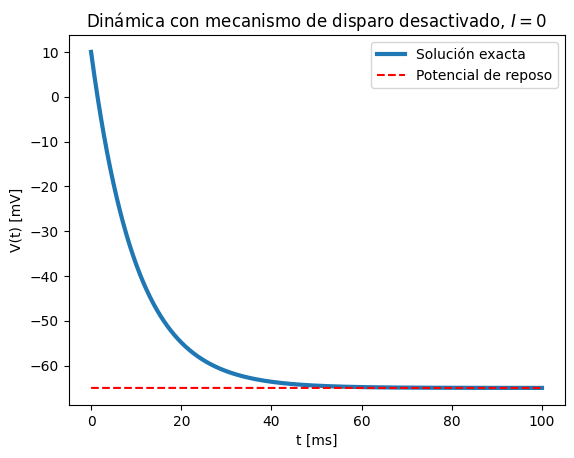

In [ ]:
# 2.2)
"""
Ahora grafiquemos la solución obtenida. Usamos V_0=10mV, t∈[0,100]ms, E≈−65mV, τ≈10ms
Primero definamos la funcion y luego la graficamos armando una matriz
"""
def sin_disparo(E, V_0, t, tau):
  return E-(E-V_0)*np.exp(-t/tau)

V_0=10
E=-65
tau=10

tiempo=np.linspace(0, 100, 10000)
V = [sin_disparo(E, V_0, t, tau) for t in tiempo]

plt.plot(tiempo, V, label="Solución exacta", linewidth=3)
plt.plot(tiempo, E*np.ones(len(tiempo)), label="Potencial de reposo", linestyle='--',c='red') # linea del potencial de reposo
plt.xlabel("t [ms]")
plt.ylabel("V(t) [mV]")
plt.title('Dinámica con mecanismo de disparo desactivado, $I=0$')
plt.legend()
plt.show()

In [ ]:
# 2.3)
"""
Realicemos el análisis geométrico
"""

'\nRealicemos el análisis geométrico\n'

Para analizar geométricamente el gráfico obtenido en el **2.2)**, veamos el lado derecho de la ODE ya que sus raíces son los puntos fijos:

\begin{eqnarray}
f(V)=\frac{1}{τ}(E-V)
\\
\\
f(V^*)=0=\frac{1}{τ}(E-V^*)
\\
\\
V^*=E
\end{eqnarray}

Entonces el puntos fijo del potencial es el potencial de reposo. Veamos su estabilidad viendo la derivada primera de f evaluada en ese punto:

\begin{eqnarray}
f'(V)=-\frac{1}{τ}
\\
\\
f'(V^*)=-\frac{1}{τ}<0 %>
\end{eqnarray}

Por lo tanto, podemos decir que el potencial de reposo es un punto fijo estable (o atractores).

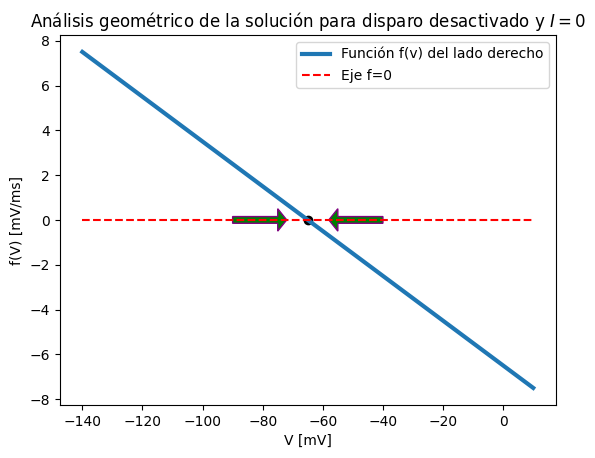

In [ ]:
"""
Grafiquemos ahora la f junto con un campo vectorial hacia el atractor
"""

valores_v=np.linspace(-140, 10, 1000)
valores_f=[(1/tau)*(E-v) for v in valores_v]

plt.plot(valores_v, valores_f, label="Función f(v) del lado derecho", linewidth=3)
plt.plot(valores_v, 0*np.ones(len(valores_v)), label="Eje f=0", linestyle='--',c='red') # punto fijo = raices de f
plt.arrow(-90,0,15,0, width=0.3, head_width=1, head_length=3, ec="purple", fc="g") # dibujo las flechitas
plt.arrow(-40,0,-15,0, width=0.3, head_width=1, head_length=3, ec="purple", fc="g") # ec=edge color, fc=face color. ver https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.arrow.html
plt.scatter([E],[0],c='black') # dibujo el punto fijo en v=E, f=0 con color negro
plt.xlabel("V [mV]")
plt.ylabel("f(V) [mV/ms]")
plt.title('Análisis geométrico de la solución para disparo desactivado y $I=0$')
plt.legend()
plt.show()

In [ ]:
# 2.4)
"""
Ahora hagamos todo lo mismo que antes pero con I=2nA.
R≈10MΩ=10*10^6Ω=1^7Ω
"""

'\nAhora hagamos todo lo mismo que antes pero con I=2nA.\nR≈10MΩ=10*10^6Ω=1^7Ω\n'

In [ ]:
# 2.4.1)
"""
Veamos la solución analítica:
"""

'\nVeamos la solución analítica:\n'

Ahora tengo la misma ecuación $\frac{dV}{dt}=\frac{1}{τ}(E-V(t)+RI(t))$ pero con las condiciones $V(0)=V_0$ y $I=2nA$.

Luego:

\begin{eqnarray}
\frac{dV}{dt}=\frac{1}{τ}(E-V(t)+RI)
\\
\\
\frac{dV}{E-V+RI}=\frac{1}{τ}dt
\\
\\
-\ln\left(\frac{E-V+RI}{E-V_0+RI}\right)=\frac{1}{τ}t
\\
\\
\frac{E-V+RI}{E-V_0+RI}=e^{-\frac{t}{τ}}
\\
\\
E-V+RI=(E-V_0+RI)e^{-\frac{t}{τ}}
\\
\\
V=E+RI-(E-V_0+RI)e^{-\frac{t}{τ}}
\end{eqnarray}

Notemos que si cambiamos el parámetro $E$ por uno que sea $\hat{E}=E+RI$, entonces:

\begin{eqnarray}
V=\hat{E}-(\hat{E}-V_0)e^{-\frac{t}{τ}},
\end{eqnarray}

que es la misma ecuación que antes pero con el cambio $E$ $->$ $\hat{E}$.

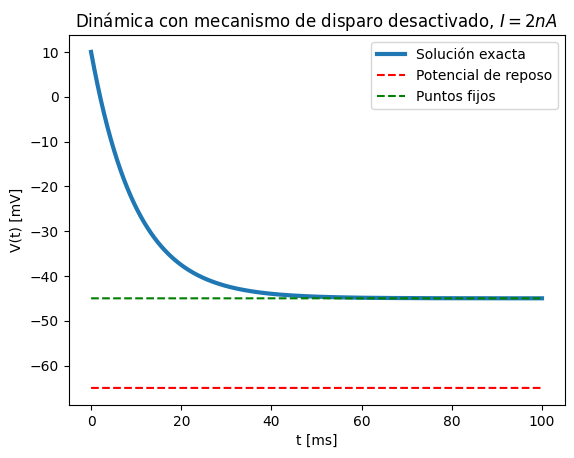

In [ ]:
# 2.4.2)
"""
Usemos entonces lo mismo que antes pero definiendo ahora nuestro nuevo E. R e I lo dejo en esas unidades pues Mohm es 10^6 y
nA es 10^-9 entonces al multiplicar queda en 10^-3 que es mili como el resto
t y tau no importan pues se cancelan
"""

R = 10 # Mohm
I = 2 # nA
E_sombrero=E+R*I

tiempo=np.linspace(0, 100, 10000)
V = [sin_disparo(E_sombrero, V_0, t, tau) for t in tiempo]

plt.plot(tiempo, V, label="Solución exacta", linewidth=3)
plt.plot(tiempo, E*np.ones(len(tiempo)), label="Potencial de reposo", linestyle='--',c='red') # linea del potencial de reposo
plt.plot(tiempo, E_sombrero*np.ones(len(tiempo)), label="Puntos fijos", linestyle='--',c='green') # Cuando V=E_sombrero puntos fijos de f
plt.xlabel("t [ms]")
plt.ylabel("V(t) [mV]")
plt.title('Dinámica con mecanismo de disparo desactivado, $I=2nA$')
plt.legend()
plt.show()

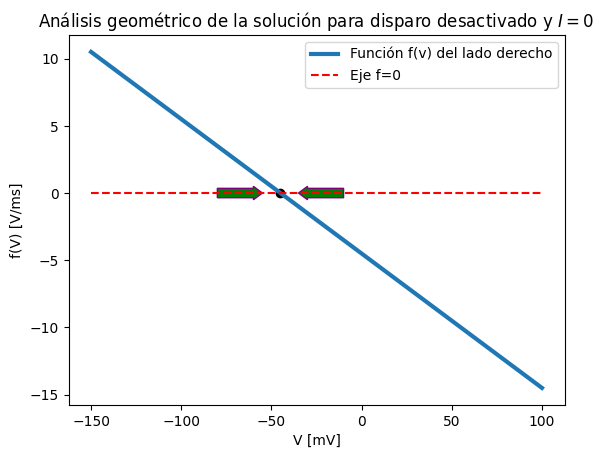

In [ ]:
# 2.4.3)
"""
Para hacer el análisis de estabilidad nos damos cuenta que tenemos el mismo caso que antes pero con E cambiado por E_sombrero.
Por lo tanto, el punto fijo es V=E_sombrero y es estable
"""

valores_v=np.linspace(-150, 100, 1000)
valores_f=[(1/tau)*(E_sombrero-v) for v in valores_v]

plt.plot(valores_v, valores_f, label="Función f(v) del lado derecho", linewidth=3)
plt.plot(valores_v, 0*np.ones(len(valores_v)), label="Eje f=0", linestyle='--',c='red') # punto fijo = raices de f
plt.arrow(-80,0,20,0, width=0.7, head_width=1, head_length=5, ec="purple", fc="g") # dibujo las flechitas
plt.arrow(-10,0,-20,0, width=0.7, head_width=1, head_length=5, ec="purple", fc="g") # ec=edge color, fc=face color. ver https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.arrow.html
plt.scatter([E_sombrero],[0],c='black') # dibujo el punto fijo en v=E_sombrero, f=0 con color negro
plt.xlabel("V [mV]")
plt.ylabel("f(V) [V/ms]")
plt.title('Análisis geométrico de la solución para disparo desactivado y $I=0$')
plt.legend()
plt.show()

Notemos que podríamos hacer todo esto sin la redefinición de la energía, usando una nueva función que cumpla:

\begin{eqnarray}
V=E+RI-(E-V_0+RI)e^{-\frac{t}{τ}}
\end{eqnarray}

Veamos si da lo mismo usando esto:

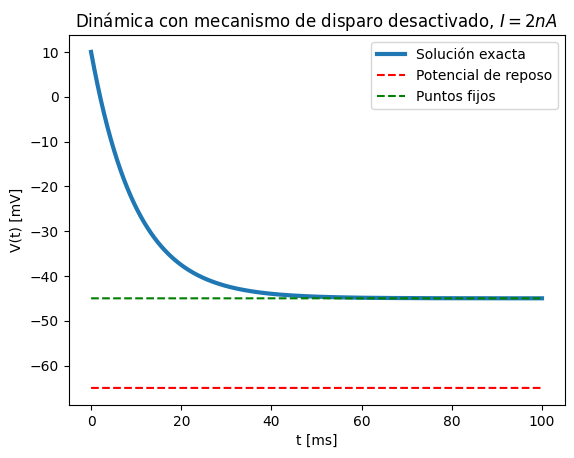

In [ ]:
"""
Por lo tanto, definimos la función con_disparo_cte
"""
def sin_disparo_I_cte(E, V_0, R, I, t, tau):
  return E+R*I-(E-V_0+R*I)*np.exp(-t/tau)

# ya tenemos todos los parámtetros definidos

tiempo=np.linspace(0, 100, 10000)
V = [sin_disparo_I_cte(E, V_0, R, I, t, tau) for t in tiempo]

plt.plot(tiempo, V, label="Solución exacta", linewidth=3)
plt.plot(tiempo, E*np.ones(len(tiempo)), label="Potencial de reposo", linestyle='--',c='red') # linea del potencial de reposo
plt.plot(tiempo, E_sombrero*np.ones(len(tiempo)), label="Puntos fijos", linestyle='--',c='green')
plt.xlabel("t [ms]")
plt.ylabel("V(t) [mV]")
plt.title('Dinámica con mecanismo de disparo desactivado, $I=2nA$')
plt.legend()
plt.show()



Y ahí puede verse que da lo mismo.

In [ ]:
# 2.5)
"""
Veamos por último la solución analítica para una I que depende del tiempo
"""

'\nVeamos por último la solución analítica para una I que depende del tiempo\n'

Finalmente, tengo la misma ecuación $\frac{dV}{dt}=\frac{1}{τ}(E-V(t)+RI(t))$ más general, ahora la corriente depende del tiempo.

Luego:

\begin{eqnarray}
\frac{dV}{dt}=\frac{1}{τ}(E-V(t)+RI(t))
\\
\\
\frac{dV}{dt} + \frac{1}{τ} V(t)=\frac{1}{τ}(E+RI(t))
\end{eqnarray}

Que es una EDO lineal, ya que cumple:

\begin{eqnarray}
V'+P(t)V=Q(t),
\end{eqnarray}

con:

\begin{eqnarray}
P(t)=\frac{1}{τ},
\\
Q(t) = \frac{1}{τ}(E+RI(t)).
\end{eqnarray}

Este tipo de EDO tienen como solución:

\begin{eqnarray}
V(t)=e^{-∫P(t)dt}.\left(c+∫Q(t)e^{∫P(t)dt}dt \right).
\end{eqnarray}

En nuestro caso particular tenemos (usando condicion inicial $V(0)=V_0$):
\begin{eqnarray}
∫P(t)dt=∫\frac{1}{τ}dt=\frac{t}{τ}
\\
\\
∫Q(t)e^{∫P(t)dt}dt=∫\frac{1}{τ}(E+RI(t))e^\frac{t}{τ}dt
\\
\\
c=V_0
\end{eqnarray}

Por lo tanto, se llega a:
\begin{eqnarray}
V(t)=e^{-\frac{t}{τ}}.\left(V_0+\frac{1}{τ}∫_{0}^{t}(E+RI(t'))e^\frac{t'}{τ}dt' \right)
\end{eqnarray}

Si en lugar de la condición $V(0)=V_0$ tuvieramos la más general posible ($V(t_0)$ arbitraria), entonces la ecuación anterior se convierte en:

\begin{eqnarray}
V(t)=e^{-\frac{t-t_0}{τ}}.\left(V_0+\frac{1}{τ}∫_{t_0}^{t}(E+RI(t'))e^\frac{t'-t_0}{τ}dt' \right)
\end{eqnarray}

## **Ejercicio 3)** Dinámica con mecanismo de disparo activado

**1)** Resuelva numéricamente la ODE del modelo *Integrate and Fire* en el intervalo $t\in [0,200]ms$ para la condición inicial $V(0)=E$ y una corriente de entrada $I(t)=I_0$ para todo $t$ con $I_0=2nA$. Utilice el paso de integración $h=0.05ms$.

**2)** Grafique la solución computada en el inciso **3.1)**. Incorpore al gráfico la solución exacta del inciso **2.1)**, en donde el mecanismo de disparo está desactivado, para la misma condición inicial del inciso **3.1)**. Grafique, también, líneas punteadas horizontales marcando los valores de $V^*$ y $V_u$, donde $V^*$ es el valor de $V$ tal que $f(V)=0$.

**3)** Para el caso indicado en el inciso **3.1)**, calcule analíticamente el período de disparo.
Observe si el valor computado corresponde con el observado en el inciso **3.2)**.
Grafíque la frencuencia en función de $I_0$.
Que ocurre para valores pequeños de $I_0$?


**4)** Repita **3.1)** y **3.2)** con $I_e(t)=I_0 \cos(t/30ms)$ e $I_0=2.5nA$ para $0\,ms\leq t\leq 500\,ms$. En este caso, no incluya la solución exacta del inciso **2.1)**, pero sí lineas punteadas horizontales para marcar los valores de $E$ y $V_u$.

**5)** Repita **3.1)** y **3.2)** con

\begin{equation}
I(t)= I_0 \, \left(
    \cos{\left( \frac{t}{3ms} \right)} +
    \sin{\left( \frac{t}{5ms} \right)} +
    \cos{\left( \frac{t}{7ms} \right)} +
    \sin{\left( \frac{t}{11ms} \right)} +
    \cos{\left( \frac{t}{13ms} \right)}  \right)^2 \, nA \,
    \;\;\;(4)
\end{equation}

e $I_0=0.35 nA$ para $0\,ms\leq t\leq 200\,ms$. Al igual que en inciso anterior, no incluya la solución exacta del inciso **2.a)**, pero sí lineas punteadas horizontales para marcar los valores de $E$ y $V_u$.

In [ ]:
# 3.1)
"""
Ahora tenemos corriente constante igual que al final, pero lo vamos a resolver numéricamente
Volvamos a definir los parámetros
"""
E = -65 # mV
V_0 = E
tau = 10 # ms
R = 10 # Mohm
I = 2 # nA
E_sombrero = E + R*I

# R e I lo dejo en esas unidades pues Mohm es 10^6 y nA es 10^-9 entonces al multiplicar queda en 10^-3 que es mili como el resto

# Ahora vamos a aplicar los metodos vistos en la guía 4. Para esto, vamos a definir a la funci+on f del lado derecho de la ODE:

def f(x, t, p):
  """
  tau = p[0]
  E = p[1]
  R = p[2]
  I = p[3]
  """
  return (1/p[0])*(p[1] - np.array(x[0]) + p[2]*p[3]) # aunque tenemos 1 sola coordenada, igual debemos armar un vector x (corresponde a v)

# debemos activarle el mecanismo de disparo. Esto es una función condicionante que si se cumple que V>V_u entonces V tiende a E

V_u = -50

def cond(x, t, p):
  V   = x[0]
  E   = p[1]
  if V>V_u:
    V=E
  return np.array([V])

xa=np.array([E]) # v(0)
a=0 # tiempo inicial
b=200 # tiempo final
p=np.array([tau, E, R, I])
h=0.05 # ms

# h=(b-a)/k entonces k=(b-a)/h
k=int((b-a)/h)

w, t = ode.integracion_ode(ode.rk4, f, xa, a, b, k, p, c=cond)

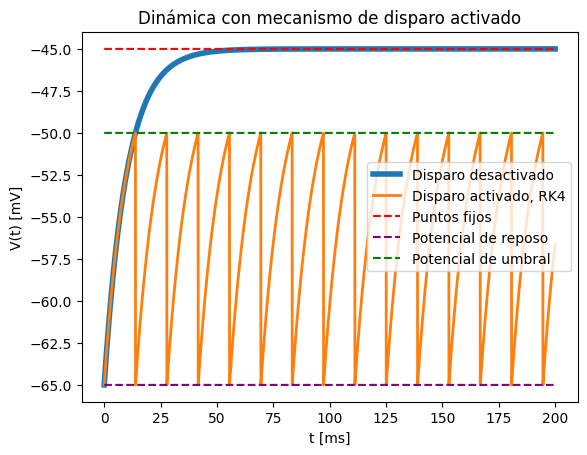

In [ ]:
# 3.2)
tiempo=np.linspace(a, b, 10000)
V = [sin_disparo_I_cte(E, V_0, R, I, t, tau) for t in tiempo]

plt.plot(tiempo, V, label="Disparo desactivado", linewidth=4)
plt.plot(t, w[0,:], label="Disparo activado, RK4", linewidth=2)
plt.plot(t, E_sombrero*np.ones(len(t)), label="Puntos fijos", linestyle='--',c='red') # f(V*)=0 cuando V*=E+R*I
plt.plot(t, E*np.ones(len(t)), label="Potencial de reposo", linestyle='--',c='purple') # potencial de reposo
plt.plot(t, V_u*np.ones(len(t)), label="Potencial de umbral", linestyle='--',c='green') # linea del potencial de reposo
plt.xlabel("t [ms]")
plt.ylabel("V(t) [mV]")
plt.title('Dinámica con mecanismo de disparo activado')
plt.legend()
plt.show()

In [ ]:
# 3.3)

Un período en física está definido como: "el tiempo necesario para que un ciclo completo de vibración pase en un punto dado".
Por lo tanto, para calcularlo de forma analítica podemos ver el tiempo que tarda la neurona desde cuando está en el potencial de reposo hasta que vuelve a estarlo.
Basta ver el tiempo que tarda desde el principio en disparar por primera vez. Usamos la ecuación vista en el ejercicio 2.4:

\begin{eqnarray}
V=\hat{E}-(\hat{E}-V_0)e^{-\frac{t}{τ}},
\end{eqnarray}

y debemos ver para que tiempo $t_1$ el voltaje es el potencial de umbral $V_u$:

\begin{eqnarray}
V_u=\hat{E}-(\hat{E}-V_0)e^{-\frac{t_1}{τ}}
\\
\\
\hat{E}-V_u=(\hat{E}-V_0)e^{-\frac{t_1}{τ}}
\\
\\
\frac{\hat{E}-V_u}{\hat{E}-V_0}=e^{-\frac{t_1}{τ}}
\\
\\
\ln\left(\frac{\hat{E}-V_u}{\hat{E}-V_0}\right)=-\frac{t_1}{τ}
\\
\\
t_1=-τ\ln\left(\frac{\hat{E}-V_u}{\hat{E}-V_0}\right)
\end{eqnarray}

Usando que $\hat{E}=E+RI_0$ y que en este caso $V_0=E$ entonces la ecuación queda de la forma:

\begin{eqnarray}
t_1=-τ\ln\left(\frac{E+RI_0-V_u}{RI_0}\right)
\end{eqnarray}

Donde sabemos los valores de todos los parámetros.

In [ ]:
# veamos cuanto vale t_1

t_1 = -tau*np.log((E+R*I-V_u)/(R*I))
t_1

13.862943611198906

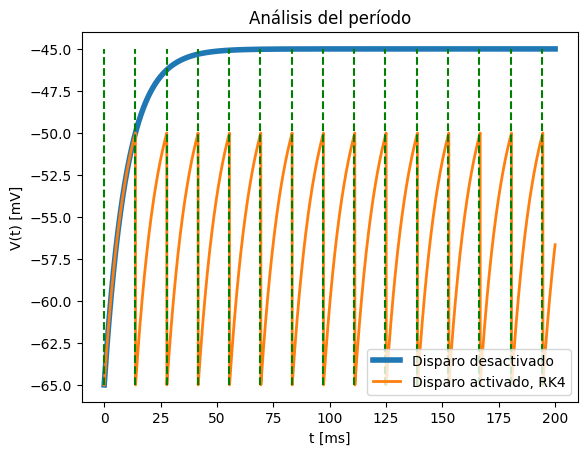

In [ ]:
# veamos si esto concuerda con el gráfico anterior

t_periodo=np.arange(0, 200, t_1)
v_periodo=np.linspace(E, E_sombrero, 1000)

plt.plot(tiempo, V, label="Disparo desactivado", linewidth=4)
plt.plot(t, w[0,:], label="Disparo activado, RK4", linewidth=2)
for i in range(len(t_periodo)):
  plt.plot(t_periodo[i]*np.ones(len(v_periodo)), v_periodo, linestyle='--',c='green') # f(V*)=0 cuando V*=E+R*I
plt.xlabel("t [ms]")
plt.ylabel("V(t) [mV]")
plt.title('Análisis del período')
plt.legend()
plt.show()

Donde puede verse que el período es la distancia entre las líneas punteadas verdes.
Ahora grafiquemos la frencuencia en función de $I_0$. Para esto debemos recordar que la frecuencia es la inversa del período ($f=\frac{1}{T}$)

\begin{eqnarray}
T=-τ\ln\left(\frac{E+RI_0-V_u}{RI_0}\right)
\\
\\
f=-\frac{1}{τ\ln\left(\frac{E+RI_0-V_u}{RI_0}\right)}
\end{eqnarray}

Donde ahora usaremos como variable independiente a la corriente constante.

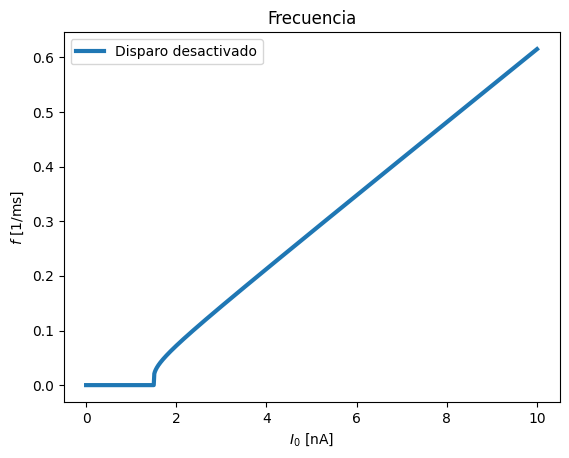

In [ ]:
# notemos que para I<1.5 lo que está dentro del logaritmo se hace 0 entonces el ln se va a -inf y por lo tanto la frecuencia se va a cero.
# para mostrar eso en el grafico vamos a definir la función como 0 desde 0 hasta 1.5 y luego con la formula.

I_1 = np.linspace(0, 1.5, 1000)
frec_1 = np.zeros(len(I_1))
I_2 = np.linspace(1.51, 10, 10000)
frec_2=[-1/(tau*np.log((E+R*i-V_u)/(R*i))) for i in I_2]

I_0 = np.concatenate((I_1, I_2))
frec = np.concatenate((frec_1, frec_2))

plt.plot(I_0, frec, label="Disparo desactivado", linewidth=3)
plt.xlabel("$I_0$ [nA]")
plt.ylabel("$f$ [1/ms]")
plt.title('Frecuencia')
plt.legend()
plt.show()

In [ ]:
# 3.4)

En este caso tenemos un problema numérico con una corriente no constante. Por lo tanto, no podemos poner a $I$ dentro del vector de parámetros. Por lo tanto, vamos a redefinir la función $f(V, t)$


\begin{eqnarray}
\frac{dV}{dt}=\frac{1}{\tau}\left(E-V(t)+RI(t)\right)
\\
\\
\frac{dV}{dt}=\frac{1}{\tau}\left(E-V(t)+RI_0\cos\left(\frac{t}{30ms}\right)\right)
\end{eqnarray}

In [ ]:
"""
Volvemos a definir los parámetros. y la función f que ahora será g. La condición seguirá siendo la misma
"""

E = -65 # mV
V_0 = E
tau = 10 # ms
R = 10 # Mohm
I_0 = 2.5 # nA

def g(x, t, p):
  """
  tau = p[0]
  E = p[1]
  R = p[2]
  I_0 = p[3]
  """
  return (1/p[0])*(p[1] - np.array(x[0]) + p[2]*p[3]*np.cos(t/30))


xa=np.array([E]) # v(0)
a=0 # tiempo inicial
b=500 # tiempo final

p=np.array([tau, E, R, I_0])
h=0.05 # ms

# h=(b-a)/k entonces k=(b-a)/h
k=int((b-a)/h)

w, t = ode.integracion_ode(ode.rk4, g, xa, a, b, k, p,c=cond)

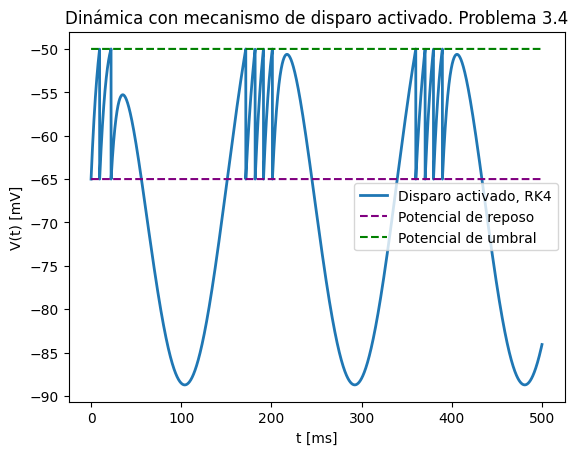

In [ ]:
plt.plot(t, w[0,:], label="Disparo activado, RK4", linewidth=2)
plt.plot(t, E*np.ones(len(t)), label="Potencial de reposo", linestyle='--',c='purple') # potencial de reposo
plt.plot(t, V_u*np.ones(len(t)), label="Potencial de umbral", linestyle='--',c='green') # linea del potencial de reposo
plt.xlabel("t [ms]")
plt.ylabel("V(t) [mV]")
plt.title('Dinámica con mecanismo de disparo activado. Problema 3.4')
plt.legend()
plt.show()

In [ ]:
# 3.5)

Veamos por último otro problema numérico con una corriente no constante pero distinta a la anterior. Redefinamos la función $f(V, t)$

\begin{eqnarray}
\frac{dV}{dt}=\frac{1}{\tau}\left(E-V(t)+RI(t)\right)
\\
\\
\frac{dV}{dt}=\frac{1}{\tau}\left(E-V(t)+RI_0\left(\cos\left(\frac{t}{3ms}\right) + \sin\left(\frac{t}{5ms}\right) + \cos\left(\frac{t}{7ms}\right) + \sin\left(\frac{t}{11ms}\right) + \cos\left(\frac{t}{13ms}\right) \right)^2 \right)
\end{eqnarray}

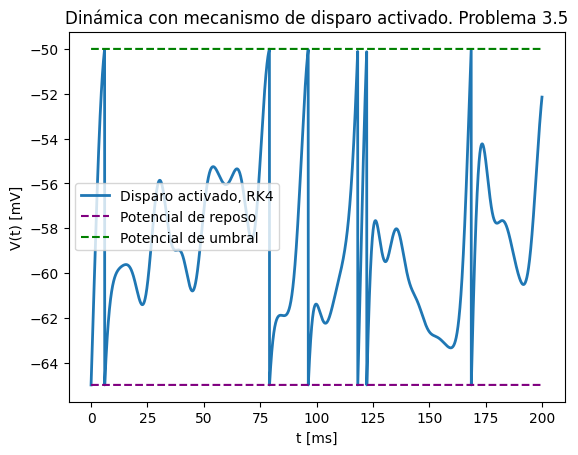

In [ ]:
"""
Volvemos a definir algunos parametros. y la función f que ahora será g_2. La condición seguirá siendo la misma
"""

E = -65 # mV
V_0 = E
tau = 10 # ms
R = 10 # Mohm
I_0 = 0.35 # nA

def g_2(x, t, p):
  """
  tau = p[0]
  E = p[1]
  R = p[2]
  I_0 = p[3]
  """
  return (1/p[0])*(p[1] - np.array(x[0]) + p[2]*p[3]*(np.cos(t/3) + np.sin(t/5) + np.cos(t/7) + np.sin(t/11) + np.cos(t/13))**2 )


xa=np.array([E]) # v(0)
a=0 # tiempo inicial
b=200 # tiempo final

p=np.array([tau, E, R, I_0])
h=0.05 # ms

# h=(b-a)/k entonces k=(b-a)/h
k=int((b-a)/h)

w, t = ode.integracion_ode(ode.rk4, g_2, xa, a, b, k, p, c=cond)

plt.plot(t, w[0,:], label="Disparo activado, RK4", linewidth=2)
plt.plot(t, E*np.ones(len(t)), label="Potencial de reposo", linestyle='--',c='purple') # potencial de reposo
plt.plot(t, V_u*np.ones(len(t)), label="Potencial de umbral", linestyle='--',c='green') # linea del potencial de reposo
plt.xlabel("t [ms]")
plt.ylabel("V(t) [mV]")
plt.title('Dinámica con mecanismo de disparo activado. Problema 3.5')
plt.legend()
plt.show()